In [57]:
# importing libraries
import pandas as pd
import matplotlib.pylab as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [58]:
data=pd.read_csv('https://raw.githubusercontent.com/thamidu02/AIML_project/refs/heads/main/data/balanced_data.csv')

In [59]:
data_df=pd.DataFrame(data)

In [60]:
data_df.head()

,age,height,weight,bmi,waist_size,blood_pressure,glucose,heart_rate,insulin,cholesterol,...,stress_level,target,gender_Female,gender_Male,job_type_Healthcare,job_type_Labor,job_type_Office,job_type_Service,job_type_Tech,job_type_Unemployed
0,-0.516129,0.532513,-0.286205,-0.466182,-0.793095,-0.048494,-0.789323,-0.065063,1.116397,-0.901466,...,0.500000,healthy,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
1,-0.451613,0.113444,0.428740,0.317736,0.882447,-0.423962,-0.704292,0.462630,-1.300426,0.015120,...,0.500000,healthy,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.193548,0.138622,-0.039458,-0.095566,0.390318,0.780589,0.265728,0.034614,-0.527712,-0.439868,...,0.833333,healthy,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.903226,1.063068,0.538649,-0.046443,0.080632,-1.164706,1.604822,-0.305074,0.264342,-1.125651,...,0.666667,healthy,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-0.483871,0.117415,0.888653,0.710070,0.229271,0.296010,0.186589,-0.014294,0.462007,-1.840230,...,-0.333333,healthy,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [61]:
data_df.columns

Index(['age', 'height', 'weight', 'bmi', 'waist_size', 'blood_pressure',
       'glucose', 'heart_rate', 'insulin', 'cholesterol', 'sugar_intake',
       'daily_steps', 'calorie_intake', 'daily_supplement_dosage',
       'water_intake', 'income', 'work_hours', 'sleep_hours',
       'work_sleep_balance', 'stress_level', 'target', 'gender_Female',
       'gender_Male', 'job_type_Healthcare', 'job_type_Labor',
       'job_type_Office', 'job_type_Service', 'job_type_Tech',
       'job_type_Unemployed'],
      dtype='object')

In [62]:
data_df.describe()

,age,height,weight,bmi,waist_size,blood_pressure,glucose,heart_rate,insulin,cholesterol,...,work_sleep_balance,stress_level,gender_Female,gender_Male,job_type_Healthcare,job_type_Labor,job_type_Office,job_type_Service,job_type_Tech,job_type_Unemployed
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.003823,0.014309,0.032780,0.060644,0.020136,-0.012667,0.047228,-0.032690,-0.005951,0.003951,...,0.127052,0.003833,0.507500,0.492500,0.169500,0.173500,0.158500,0.159500,0.173000,0.166000
std,0.579284,0.744236,0.726317,0.754748,0.748494,0.766680,0.732374,0.808740,0.793466,0.729208,...,0.821018,0.523859,0.500069,0.500069,0.375287,0.378774,0.365301,0.366233,0.378342,0.372174
min,-0.967742,-2.155411,-1.488155,-1.665177,-2.494987,-2.878071,-2.300899,-2.939604,-2.204649,-2.315525,...,-1.997276,-0.833333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-0.483871,-0.491521,-0.458288,-0.475792,-0.499730,-0.547553,-0.461426,-0.531622,-0.531502,-0.481871,...,-0.434426,-0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.009024,0.041447,0.040722,0.033636,0.002023,0.050934,-0.012009,0.003476,0.022496,...,0.018831,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.516129,0.504253,0.517436,0.545119,0.538444,0.507939,0.536331,0.473686,0.505658,0.495660,...,0.527461,0.500000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,2.585270,2.945759,3.127637,2.701138,2.501723,2.434811,2.967024,2.254904,3.201732,...,5.145421,0.833333,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [63]:
len(data_df.columns)

29

In [64]:
# splitting the target variable and input data
X,y=data_df.drop('target',axis=1),data_df['target']

In [65]:
data_df.target.value_counts()

,count
target,
healthy,1000
diseased,1000


In [66]:
# encoding the target variable
y=np.where(y=='healthy',1,0)

In [67]:
# splitting into train set and test set
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,stratify=y,test_size=0.2,random_state=42)

## Decision Tree

A Decision Tree is a supervised learning algorithm used for classification and regression tasks.

It works like a flowchart:

* Each internal node represents a test on a feature.
* Each branch represents an outcome of that test.
* Each leaf node represents a final decision or prediction.

A decision tree is built top-down using a process called recursive partitioning.

At each step, the algorithm:


1. Selects the best feature to split the data.
2. Divides the dataset into subsets based on that feature’s values.
3. Repeats the process for each subset until a stopping condition is met (e.g., max depth reached, or all samples belong to one class).

| Parameter             | Description                                             |
| --------------------- | ------------------------------------------------------- |
| **criterion**         | Function to measure split quality ('gini' or 'entropy') |
| **max_depth**         | Maximum depth of the tree (controls overfitting)        |
| **min_samples_split** | Minimum samples needed to split a node                  |
| **min_samples_leaf**  | Minimum samples needed to be at a leaf node             |
| **max_features**      | Number of features to consider at each split            |
| **random_state**      | Ensures reproducibility of results                      |


In [68]:
# import decision tree
from sklearn.tree import DecisionTreeClassifier

In [69]:
param_grid=[
    {'max_depth':[50,80,100],
     'min_samples_split':[5,6,7],
    'max_features':[5,10,15,20]}
]

In [70]:
# import grid search
from sklearn.model_selection import GridSearchCV
grid_search=GridSearchCV(DecisionTreeClassifier(random_state=42),param_grid,cv=5)
grid_search.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid=[{'max_depth': [50, 80, 100],
                          'max_features': [5, 10, 15, 20],
                          'min_samples_split': [5, 6, 7]}])

In [71]:
print(f"Best cross validation score: {grid_search.best_score_}")

Best cross validation score: 0.536875


In [72]:
print(f"Best parameters: {grid_search.best_params_}")

Best parameters: {'max_depth': 50, 'max_features': 20, 'min_samples_split': 5}


In [73]:
results=pd.DataFrame(grid_search.cv_results_)
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_max_features,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.013500,0.002430,0.002208,0.000093,50,5,5,"{'max_depth': 50, 'max_features': 5, 'min_samp...",0.518750,0.509375,0.512500,0.490625,0.571875,0.520625,0.027286,4
1,0.012188,0.001029,0.002009,0.000065,50,5,6,"{'max_depth': 50, 'max_features': 5, 'min_samp...",0.446875,0.512500,0.509375,0.487500,0.506250,0.492500,0.024415,25
2,0.011473,0.000960,0.002018,0.000082,50,5,7,"{'max_depth': 50, 'max_features': 5, 'min_samp...",0.509375,0.503125,0.509375,0.500000,0.512500,0.506875,0.004593,16
3,0.033450,0.004162,0.004460,0.001647,50,10,5,"{'max_depth': 50, 'max_features': 10, 'min_sam...",0.556250,0.468750,0.475000,0.487500,0.475000,0.492500,0.032452,25
4,0.029268,0.001721,0.003178,0.000095,50,10,6,"{'max_depth': 50, 'max_features': 10, 'min_sam...",0.456250,0.478125,0.540625,0.484375,0.487500,0.489375,0.027853,31
5,0.034330,0.005055,0.003014,0.000096,50,10,7,"{'max_depth': 50, 'max_features': 10, 'min_sam...",0.453125,0.550000,0.515625,0.478125,0.512500,0.501875,0.033342,22
6,0.033390,0.005726,0.002170,0.000245,50,15,5,"{'max_depth': 50, 'max_features': 15, 'min_sam...",0.471875,0.515625,0.487500,0.503125,0.571875,0.510000,0.034255,10
7,0.030382,0.002184,0.002072,0.000038,50,15,6,"{'max_depth': 50, 'max_features': 15, 'min_sam...",0.496875,0.462500,0.500000,0.490625,0.471875,0.484375,0.014658,34
8,0.038174,0.006082,0.002701,0.000561,50,15,7,"{'max_depth': 50, 'max_features': 15, 'min_sam...",0.521875,0.500000,0.475000,0.537500,0.515625,0.510000,0.021232,10
9,0.055992,0.009396,0.002852,0.000264,50,20,5,"{'max_depth': 50, 'max_features': 20, 'min_sam...",0.528125,0.531250,0.528125,0.587500,0.509375,0.536875,0.026472,1


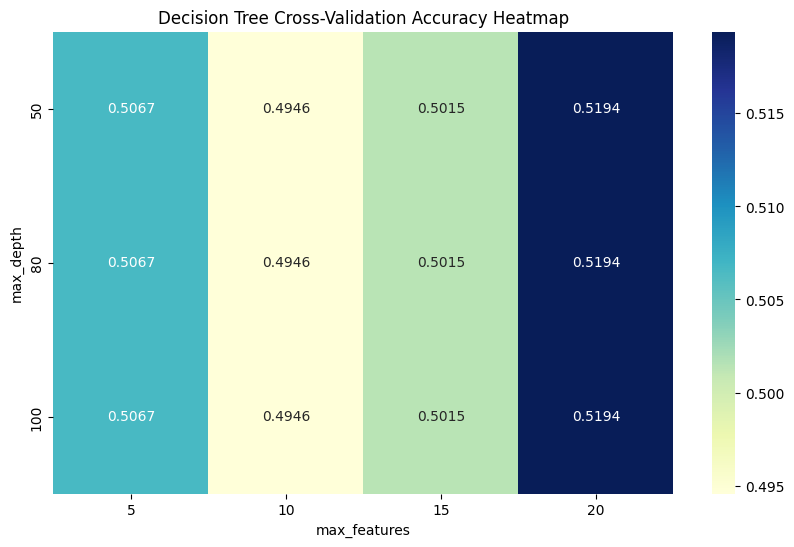

In [75]:
import seaborn as sns
# Reshape the results for the heatmap
heatmap_data = results.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_max_features'
)

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".4f", cmap="YlGnBu")
plt.title('Decision Tree Cross-Validation Accuracy Heatmap')
plt.xlabel('max_features')
plt.ylabel('max_depth')
plt.show()

In [77]:
# creating the final model using best parameters
model=DecisionTreeClassifier(**grid_search.best_params_)
model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=50, max_features=20, min_samples_split=5)

In [78]:
print(f"Test set score: {model.score(X_test,y_test)}")

Test set score: 0.48


In [79]:
y_pred=model.predict(X_test)

In [80]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.48      0.44      0.46       200
           1       0.48      0.52      0.50       200

    accuracy                           0.48       400
   macro avg       0.48      0.48      0.48       400
weighted avg       0.48      0.48      0.48       400



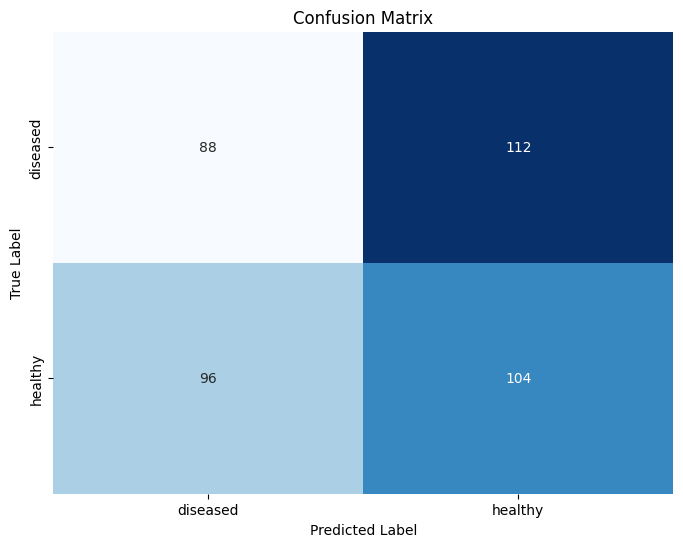

In [81]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['diseased', 'healthy'], yticklabels=['diseased', 'healthy'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()